# Modeling with SMOTE

In [84]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, cross_val_predict, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, make_scorer, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

In [85]:
DATA_DIR = r"D:\Ameng\Data Science Project\heart-failure-prediction\data"
df = pd.read_csv(os.path.join(DATA_DIR, "heart_failure_clinical_records_dataset.csv"))

In [86]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (299, 12)
y shape: (299,)


In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (239, 12)
X_test: (60, 12)


In [88]:
print("Train target distribution:")
print(y_train.value_counts())

print("\nTrain target proportion:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts())

print("\nTest target proportion:")
print(y_test.value_counts(normalize=True))

Train target distribution:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64

Train target proportion:
DEATH_EVENT
0    0.677824
1    0.322176
Name: proportion, dtype: float64

Test target distribution:
DEATH_EVENT
0    41
1    19
Name: count, dtype: int64

Test target proportion:
DEATH_EVENT
0    0.683333
1    0.316667
Name: proportion, dtype: float64


In [89]:
def build_preprocessor():
    log_cols = ["creatinine_phosphokinase", "serum_creatinine", "platelets", "time"]
    scale_cols = ["age", "ejection_fraction", "serum_sodium"]
    bin_cols = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

    log_pipeline = Pipeline([
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler())
    ])
    
    scale_pipeline = Pipeline([
        ("scale", StandardScaler())
    ])

    return ColumnTransformer([
        ("log", log_pipeline, log_cols),
        ("scale", scale_pipeline, scale_cols),
        ("pass", "passthrough", bin_cols)
    ])

## Cross Validation

In [90]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "AUC": make_scorer(roc_auc_score, response_method="predict_proba"),
    "F1": make_scorer(f1_score),
    "PRE": make_scorer(precision_score),
    "REC": make_scorer(recall_score),
}

In [91]:
smote = SMOTE(random_state=42)

models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": CalibratedClassifierCV(SVC(kernel="rbf"), ensemble=False),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42, eval_metric="logloss")
}

In [92]:
smote_models = {}

for name, model in models.items():
    smote_models[name] = ImbPipeline([
        ("preprocessor", build_preprocessor()),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

In [93]:
def cv_table(X, y, models):
    rows = []
    for name, model in models.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scorers, n_jobs=-1)

        rows.append({
            "model": name,
            "AUC": scores["test_AUC"].mean(),
            "AUC Std": scores["test_AUC"].std(),
            "F1": scores["test_F1"].mean(),
            "F1 Std": scores["test_F1"].std(),
            "PRE": scores["test_PRE"].mean(),
            "REC": scores["test_REC"].mean()
        })

    return (
        pd.DataFrame(rows)
        .set_index("model")
        .sort_values("AUC", ascending=False)
    )

In [94]:
result_smote = cv_table(X_train, y_train, smote_models)

print(result_smote.round(4))

                     AUC  AUC Std      F1  F1 Std     PRE     REC
model                                                            
XGBoost           0.9089   0.0256  0.7534  0.0635  0.7784  0.7417
RandomForest      0.9087   0.0146  0.7326  0.0387  0.7457  0.7275
LogReg            0.8998   0.0219  0.7754  0.0474  0.7511  0.8042
GradientBoosting  0.8991   0.0157  0.7371  0.0431  0.7442  0.7417
SVM               0.8928   0.0267  0.7433  0.0572  0.7254  0.7667
kNN               0.8435   0.0449  0.6554  0.0862  0.6687  0.6525


In [95]:
top3_names = (result_smote.sort_values("AUC", ascending=False).head(3).index.tolist())

print("Top 3 models:")
print(top3_names)

Top 3 models:
['XGBoost', 'RandomForest', 'LogReg']


Based on 5-fold cross-validation result, the top three models (XGBoost, Random Forest, and Logistic Regression) will be selected for hyperparameter tuning.

## Hyperparameter Tuning

In [96]:
param_lr = {
    "smote__k_neighbors": [3, 5, 7],
    "model__C": [0.01, 0.1, 1, 10, 100]
}

In [97]:
grid_lr = GridSearchCV(
    estimator=smote_models["LogReg"],
    param_grid=param_lr,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=False
)

grid_lr.fit(X_train, y_train)

print("Best param:", grid_lr.best_params_)
print("Best CV AUC:", round(grid_lr.best_score_, 4))

Best param: {'model__C': 0.01, 'smote__k_neighbors': 7}
Best CV AUC: 0.9092


In [98]:
param_rf = {
    "smote__k_neighbors": [3, 5, 7],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [99]:
grid_rf = GridSearchCV(
    estimator=smote_models["RandomForest"],
    param_grid=param_rf,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=False
)

grid_rf.fit(X_train, y_train)

print("Best param:", grid_rf.best_params_)
print("Best CV AUC:", round(grid_rf.best_score_, 4))

Best param: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'smote__k_neighbors': 5}
Best CV AUC: 0.9211


In [100]:
param_xgb = {
    "smote__k_neighbors": [3, 5, 7],
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [101]:
grid_xgb = GridSearchCV(
    estimator=smote_models["XGBoost"],
    param_grid=param_xgb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=False
)

grid_xgb.fit(X_train, y_train)

print("Best param:", grid_xgb.best_params_)
print("Best CV AUC:", round(grid_xgb.best_score_, 4))

Best param: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0, 'smote__k_neighbors': 3}
Best CV AUC: 0.923


## Tuned Model Comparison

In [102]:
tuned_results = []

if "LogReg" in top3_names:
    tuned_results.append({
        "Model": "LogReg",
        "Best CV AUC": grid_lr.best_score_,
        "Best Parameters": grid_lr.best_params_
    })

if "RandomForest" in top3_names:
    tuned_results.append({
        "Model": "RandomForest",
        "Best CV AUC": grid_rf.best_score_,
        "Best Parameters": grid_rf.best_params_
    })

if "XGBoost" in top3_names:
    tuned_results.append({
        "Model": "XGBoost",
        "Best CV AUC": grid_xgb.best_score_,
        "Best Parameters": grid_xgb.best_params_
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df.sort_values("Best CV AUC", ascending=False).round(4)

,Model,Best CV AUC,Best Parameters
2,XGBoost,0.9230,"{'model__colsample_bytree': 1.0, 'model__learn..."
1,RandomForest,0.9211,"{'model__max_depth': None, 'model__min_samples..."
0,LogReg,0.9092,"{'model__C': 0.01, 'smote__k_neighbors': 7}"


Based on hyperparameter tuning results using 5-fold cross-validation, XGBoost was selected as the best model candidate because it yielded the highest AUC (0.9230) <br>
and Precision (0.7623), with an F1-score (0.7454) close to that of Logistic Regression (0.7685). Although Logistic Regression achieved the highest Recall (0.8042), XGBoost <br>
delivered superior overall performance based on the combination of evaluation metrics.

In [103]:
best_model_name = (tuned_results_df.sort_values("Best CV AUC", ascending=False).iloc[0]["Model"])
best_model = {
    "LogReg": grid_lr.best_estimator_,
    "RandomForest": grid_rf.best_estimator_,
    "XGBoost": grid_xgb.best_estimator_
}[best_model_name]

print("Best model:", best_model_name)
print(
    "Best CV AUC:",
    round(
        tuned_results_df.loc[
            tuned_results_df["Model"] == best_model_name,
            "Best CV AUC"
        ].iloc[0],
        4
    )
)

Best model: XGBoost
Best CV AUC: 0.923


In [104]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_proba)
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

print(f"Test AUC: {test_auc:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

Test AUC: 0.8216
Test F1: 0.7027
Test Precision: 0.7222
Test Recall: 0.6842


## Threshold Optimization
F1, Precision, and Recall depend on the decision cut-off. With imbalanced data (68:32), the default threshold of 0.5 is rarely optimal. <br>
The threshold is selected based on out-of-fold (OOF) CV, not the test set, to ensure the cut-off selection is unbiased. AUC is unaffected by the threshold.

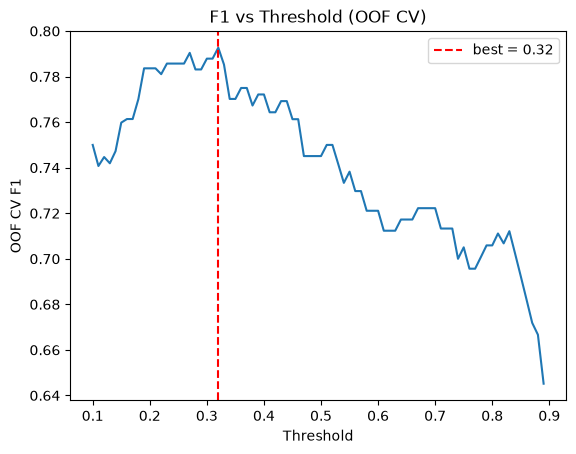

Best threshold: 0.32
OOF CV F1 best threshold: 0.7927


In [105]:
oof = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

thresholds = np.arange(0.10, 0.90, 0.01)
f1_by_t = [f1_score(y_train, oof >= t) for t in thresholds]
best_t = thresholds[np.argmax(f1_by_t)]

plt.plot(thresholds, f1_by_t)
plt.axvline(best_t, color="red", ls="--", label=f"best = {best_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("OOF CV F1")
plt.legend()
plt.title("F1 vs Threshold (OOF CV)")
plt.show()

print("Best threshold:", round(best_t, 2))
print("OOF CV F1 best threshold:", round(max(f1_by_t), 4))

In [106]:
y_pred_default = (y_proba >= 0.50).astype(int)
y_pred_opt = (y_proba >= best_t).astype(int)

rows = []
for name, yp in [("default (0.5)", y_pred_default),
                 (f"optimized ({best_t:.2f})", y_pred_opt)]:
    rows.append({"threshold": name,
                 "F1": f1_score(y_test, yp),
                 "PRE": precision_score(y_test, yp),
                 "REC": recall_score(y_test, yp)})

print(pd.DataFrame(rows).round(4))
print("Test AUC (threshold-independent):", round(test_auc, 4))

          threshold      F1     PRE     REC
0     default (0.5)  0.7027  0.7222  0.6842
1  optimized (0.32)  0.6667  0.6500  0.6842
Test AUC (threshold-independent): 0.8216


In [107]:
y_proba = best_model.predict_proba(X_test)[:, 1]

y_pred_default = (
    y_proba >= 0.50
).astype(int)

y_pred_opt = (
    y_proba >= best_t
).astype(int)

threshold_results = pd.DataFrame([
    {
        "Threshold": 0.50,
        "F1": f1_score(y_test, y_pred_default),
        "Precision": precision_score(y_test, y_pred_default),
        "Recall": recall_score(y_test, y_pred_default)
    },
    {
        "Threshold": best_t,
        "F1": f1_score(y_test, y_pred_opt),
        "Precision": precision_score(y_test, y_pred_opt),
        "Recall": recall_score(y_test, y_pred_opt)
    }
])

threshold_results.round(4)

,Threshold,F1,Precision,Recall
0,0.50,0.7027,0.7222,0.6842
1,0.32,0.6667,0.6500,0.6842


## Results Visualization

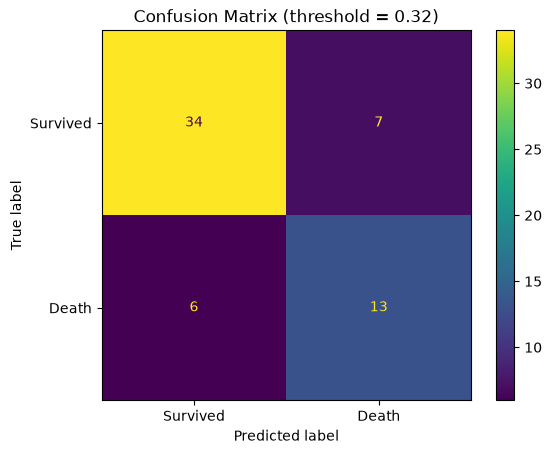

In [108]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    display_labels=["Survived", "Death"])
plt.title(f"Confusion Matrix (threshold = {best_t:.2f})")
plt.show()

The confusion matrix at a threshold of 0.32 shows 34 True Negatives, 13 True Positives, 7 False Positives, and 6 False Negatives. The model successfully detected <br>
13 out of 19 Death cases (Recall: 68.42%). Adjusting the threshold improved the model's ability to detect Death cases compared to the default threshold of 0.5, although 6 <br>
False Negative cases remained.

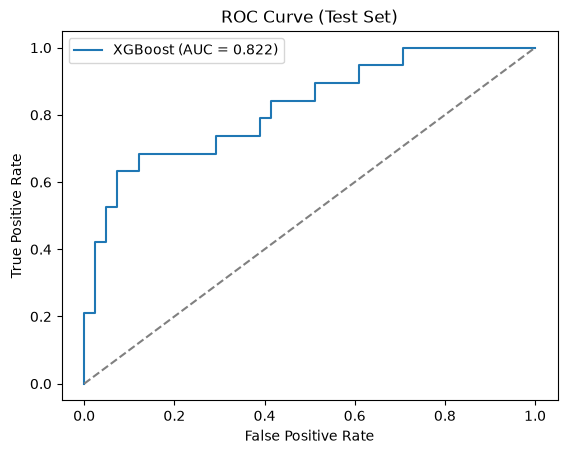

In [109]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve (Test Set)")
plt.show()

The XGBoost ROC curve on the test set yielded an AUC of 0.822, indicating good discrimination capability in distinguishing between the 'Survived' and 'Death' classes. <br>
The curve lies well above the random classifier line, demonstrating that the model performs better than random prediction.

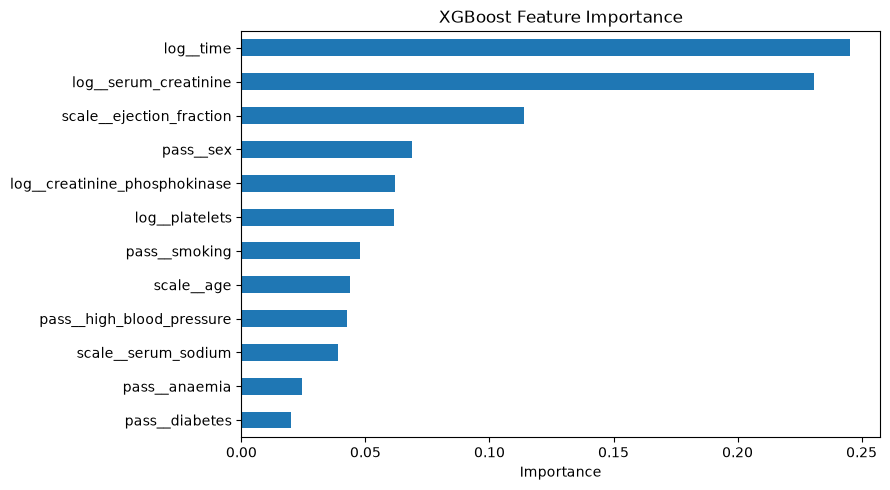

In [110]:
model_step = best_model.named_steps["model"]
preprocessor_step = best_model.named_steps["preprocessor"]

if hasattr(model_step, "feature_importances_"):
    feature_names = (preprocessor_step.get_feature_names_out())
    importance = pd.Series(model_step.feature_importances_, index=feature_names).sort_values()
    importance.plot(kind="barh", figsize=(9, 5))

    plt.title(f"{best_model_name} Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

## Export Model Result

In [111]:
MODELS_DIR = r"D:\Ameng\Data Science Project\heart-failure-prediction\models"
os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(best_model, os.path.join(MODELS_DIR, "model_smote.joblib"))

metrics = pd.DataFrame([
    {"metric": "AUC", "value": test_auc},
    {"metric": "F1 (optimized)", "value": f1_score(y_test, y_pred_opt)},
    {"metric": "Precision (optimized)", "value": precision_score(y_test, y_pred_opt)},
    {"metric": "Recall (optimized)", "value": recall_score(y_test, y_pred_opt)},
    {"metric": "best_threshold", "value": best_t},
])
metrics.to_csv(os.path.join(MODELS_DIR, "metrics_test_smote.csv"), index=False)
print("Model & metrics saved to:", MODELS_DIR)

Model & metrics saved to: D:\Ameng\Data Science Project\heart-failure-prediction\models
